# Addressing the Tutor's Outstanding Comments — Scaleup Attribution Analysis

This notebook responds to the outstanding methodological comments raised by the thesis tutor (Andre)
regarding the scaleup attribution results. It is **read-only** with respect to all data artefacts: it
loads the existing gold and silver parquet files, recomputes derived quantities in memory, and writes
only publication-ready figures to `figures/scaleup/`.

The analysis is reported in a formal, third-person register; British spelling is used (analyse,
behaviour, utilise, whilst). Each metric is introduced with its formal term, a plain-language gloss,
and — where helpful — a concrete example.

**How to read this notebook.** Every analysis section is labelled with the tutor's question it answers,
the figure or table that answers it, a short **Key findings** box, and an **In plain terms** note
explaining what the result means and why it matters. Each code cell also carries a one-line `# Andre #N`
comment naming the question it serves.

**Comments addressed:** citation-count distributions (#3), entailment-score distribution (#4),
threshold-sensitivity of AIS and PAWC (#5), the tutor's alternative coverage metric (#6), qualitative
face-validity of individual responses (#7), claim identification and multi-source handling (#9–#11).

## Section 0 — Setup, helpers, and data loading

Imports the analysis libraries, fixes a clean publication style and a consistent per-engine colour
palette, defines the artefact classifier and a small set of reusable plotting helpers (`save`, `grid6`,
`sweep_fig`, `cov_scatter`) that keep every later cell to a few lines, and loads the four read-only input
files. The artefact classifier (`is_artifact`) identifies *non-claim* segments — headings, bare URLs,
horizontal rules, and very short fragments — that the regex sentence splitter produces but which do not
constitute attributable claims.

In [1]:
%matplotlib inline
import os, re, glob
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display

# resolve the project root so relative data paths work irrespective of launch directory
_guard = 0
while not os.path.isdir('data/scaleup/gold') and _guard < 6:
    os.chdir('..'); _guard += 1
print('working directory:', os.getcwd())

sns.set_theme(style='white')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'axes.grid': False, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 13, 'axes.labelsize': 12, 'font.size': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10,
})
DPI, FIGDIR = 300, 'figures/scaleup'
os.makedirs(FIGDIR, exist_ok=True)

ENGINE_ORDER = ['chatgpt', 'claude', 'gemini', 'kimi', 'perplexity']
ENGINE_LABEL = {'chatgpt': 'ChatGPT', 'claude': 'Claude', 'gemini': 'Gemini', 'kimi': 'Kimi', 'perplexity': 'Perplexity'}
PALETTE = {'chatgpt': '#4285F4', 'claude': '#B4533A', 'gemini': '#34A853', 'kimi': '#7B1FA2', 'perplexity': '#FF6D01'}


def is_artifact(text: str) -> bool:
    # non-claim segment? heading / bare URL / rule / Sources: label / <=3 words / short stub
    t = text.strip()
    if not t or t.startswith('#') or len(t.split()) <= 3:
        return True
    if re.match(r'^(sources?|references?|citations?)\s*:?\s*$', t, re.IGNORECASE):
        return True
    return bool(re.match(r'^(https?://\S+|[-*=_]{3,}\s*|[\#\-\*\d\.\s]{1,10})$', t))


def _L(x):
    return x.tolist() if isinstance(x, np.ndarray) else x

def survivors_of(sd):
    return [e for e in _L(sd) if not is_artifact(str(e.get('text', '')))]

def scores_of(entry):
    return [float(s['score']) for s in (_L(entry.get('source_scores')) or [])]

def andre_coverage_of(sd):
    # tutor's metric: position-weighted AIS at tau=0.50 using the stored binary support flag
    s = survivors_of(sd); n = len(s)
    if n == 0:
        return np.nan
    num = den = 0.0
    for k, e in enumerate(s, start=1):
        w = (n - k + 1) / n; den += w
        if bool(e.get('supported', False)):
            num += w
    return num / den if den > 0 else np.nan


def save(fig, name):
    # tight layout, write a 300-DPI PNG, and show inline
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/{name}.png', dpi=DPI, bbox_inches='tight')
    plt.show()

def grid6(data_fn, title_fn, xlabel, ylabel, name, sup, vline=None, xlim=None, ylim=None, **hist_kw):
    # 2x3 per-engine histogram panel (6th axis blanked)
    fig, axes = plt.subplots(2, 3, figsize=(14, 7.5)); axes = axes.ravel()
    for i, eng in enumerate(ENGINE_ORDER):
        ax = axes[i]; d = data_fn(eng)
        ax.hist(d, color=PALETTE[eng], edgecolor='white', **hist_kw)
        if vline is not None: ax.axvline(vline, color='red', linestyle='--', linewidth=1.2)
        ax.set_title(title_fn(eng, d)); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        if xlim is not None: ax.set_xlim(*xlim)
        if ylim is not None: ax.set_ylim(*ylim)
    axes[5].axis('off'); fig.suptitle(sup, y=1.00); save(fig, name)

def sweep_fig(prefix, marker, ylabel, title, name, mean_label, rank_label):
    # line chart of per-engine mean metric vs threshold, plus mean and ranking tables
    means = sweep.groupby('engine')[[f'{prefix}_{t}' for t in THRESHOLDS]].mean().reindex(ENGINE_ORDER)
    means.columns = THRESHOLDS
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    for eng in ENGINE_ORDER:
        ax.plot(THRESHOLDS, means.loc[eng].values, marker=marker, linewidth=2.2, color=PALETTE[eng], label=ENGINE_LABEL[eng])
    ax.axvline(0.50, color='grey', linestyle=':', linewidth=1)
    ax.set_xlabel('Entailment threshold $\\tau$'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_xticks(THRESHOLDS); ax.set_ylim(0, 1); ax.legend(title='Engine', frameon=False)
    save(fig, name)
    disp = means.copy(); disp.index = [ENGINE_LABEL[e] for e in disp.index]
    disp.columns = [f'tau={t:.2f}' for t in THRESHOLDS]
    print(f'Mean {mean_label} by engine and threshold:'); display(disp.round(4))
    rank = pd.DataFrame({f'tau={t:.2f}': [ENGINE_LABEL[e] for e in means[t].sort_values(ascending=False).index]
                         for t in THRESHOLDS}, index=[f'Rank {i}' for i in range(1, 6)])
    print(f'{rank_label} ranking at each threshold:'); display(rank)

def cov_scatter(ycol, ylabel, rho, title, name, identity=False):
    fig, ax = plt.subplots(figsize=(7, 6.2))
    for eng in ENGINE_ORDER:
        d = work[work.engine == eng]
        ax.scatter(d['andre_coverage'], d[ycol], s=9, alpha=0.30, color=PALETTE[eng], edgecolors='none', label=ENGINE_LABEL[eng])
    if identity: ax.plot([0, 1], [0, 1], color='grey', linestyle=':', linewidth=1)
    ax.set_xlabel('andre_coverage (position-weighted AIS)'); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    lg = ax.legend(title='Engine', frameon=False, markerscale=2)
    for h in lg.legend_handles: h.set_alpha(1)
    save(fig, name)


CLEANED = 'data/scaleup/silver/nli_scaleup_cleaned.parquet'
V2      = 'data/scaleup/silver/nli_scaleupv2.parquet'
CELLAGG = 'data/scaleup/gold/cell_aggregates_scaleup.parquet'
RESP    = 'data/scaleup/silver/responses_scaleup.parquet'
INPUTS = [CLEANED, V2, CELLAGG, RESP]
# fingerprint inputs so the final cell can confirm nothing was modified
_INPUT_FINGERPRINT = {p: (os.path.getsize(p), round(os.path.getmtime(p), 3)) for p in INPUTS}

cleaned = pd.read_parquet(CLEANED)
v2      = pd.read_parquet(V2)
cellagg = pd.read_parquet(CELLAGG)
resp    = pd.read_parquet(RESP)

for name, df in [('nli_scaleup_cleaned', cleaned), ('nli_scaleupv2', v2),
                 ('cell_aggregates_scaleup', cellagg), ('responses_scaleup', resp)]:
    print(f'{name:26s} shape={df.shape}')
    print('   columns:', list(df.columns))

working directory: /Users/ganenthraravindran/Desktop/Thesis Data Pilot


nli_scaleup_cleaned        shape=(9992, 20)
   columns: ['n_sentences', 'n_sources_cited', 'n_sources_fetched_ok', 'ais_supported_sentences', 'ais_rate', 'sentence_detail', 'pawc_by_source_position', 'pawc_total', 'nli_evaluations', 'input_tokens', 'output_tokens', 'engine', 'query_id', 'run_index', 'n_response_words', 'n_artifacts', 'cleaned_n', 'cleaned_ais', 'cleaned_pawc_total', 'pawc_norm']
nli_scaleupv2              shape=(9992, 15)
   columns: ['n_sentences', 'n_sources_cited', 'n_sources_fetched_ok', 'ais_supported_sentences', 'ais_rate', 'sentence_detail', 'pawc_by_source_position', 'pawc_total', 'nli_evaluations', 'input_tokens', 'output_tokens', 'engine', 'query_id', 'run_index', 'n_response_words']
cell_aggregates_scaleup    shape=(1249, 16)
   columns: ['engine', 'query_id', 'pawc_mean', 'pawc_sd', 'pawc_cv', 'ais_mean', 'ais_sd', 'ais_cv', 'n_runs', 'n_runs_ais', 'did_search_rate', 'citations_consistent', 'n_cited_mean', 'pawc_norm_mean', 'pawc_norm_sd', 'pawc_norm_cv']
r

### A note on sample sizes — the three analysis populations

The metrics reported below are defined over **different subsets** of the 9,992 scaleup responses, because
each is undefined for certain response types, and those responses are *excluded* rather than scored as
zero. Three population sizes recur throughout the notebook and reconcile exactly:

| N | Population | Excluded |
|------:|-----------|----------|
| **9,992** | All responses | — (used for the citation counts in §1 and the raw entailment-score pool in §5) |
| **9,986** | Responses with at least one genuine claim ($N^{*} \geq 1$) | the **6** *all-artefact* responses, whose segments are entirely headings, URLs or stubs, so cleaned AIS and `andre_coverage` are undefined |
| **7,131** | Responses that *also* fetched at least one source ($M \geq 1$) | the **2,861** *no-search / no-fetch* responses, for which PAWC$_{norm}$ — normalised by $M \cdot \Omega$ — is undefined |

The arithmetic reconciles exactly: $9{,}992 - 6 = 9{,}986$ and $9{,}992 - 2{,}861 = 7{,}131$. The 2,861
no-fetch cells are dominated by **ChatGPT's search-abstention** (1,586; it frequently answers from
parametric memory without invoking web search), followed by Gemini (655), Claude (533), Kimi (80) and
Perplexity (7) — these are tabulated in §2. Consequently, every figure or correlation involving
PAWC$_{norm}$ reports $n = 7{,}131$, whereas the coverage/AIS quantities report $n = 9{,}986$; the gap
between the two is essentially the rate at which engines answered without fetching a source.

## Section 1 — Citation-count distributions

**Andre's question (#3):** *"For each model, produce a histogram of the number of cited sources."*

The **citation count** of a response is the number of distinct sources the engine explicitly cites
(`n_sources_cited`); it measures *citation behaviour*, distinct from whether those citations actually
support the text. The figure shows one histogram per engine; the table reports the per-engine median,
mean, maximum, and percentage of zero-citation responses.

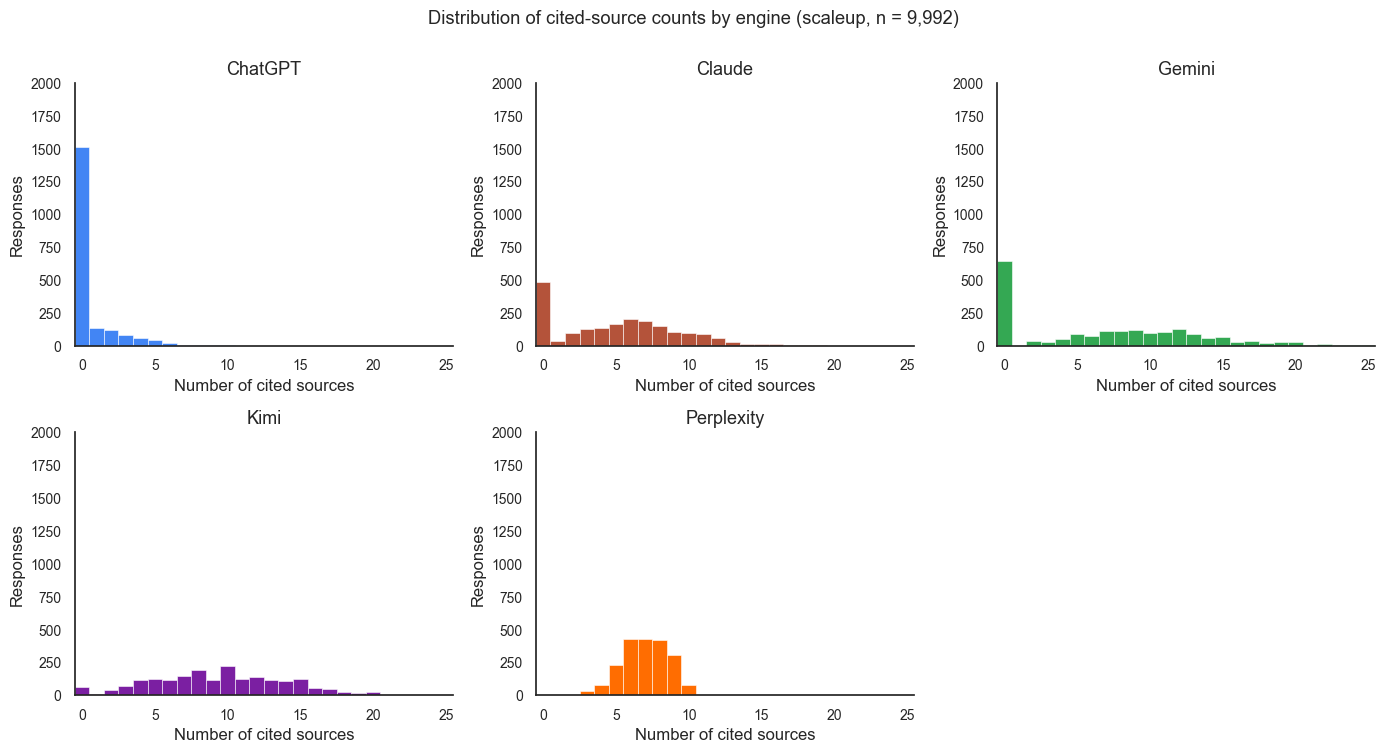

Per-engine cited-source counts (median, mean, max, % zero-citation):


,median,mean,max,pct_zero
ChatGPT,0.0,0.70,12,75.75
Claude,5.0,5.16,19,24.25
Gemini,7.0,7.13,38,32.25
Kimi,10.0,9.47,32,2.96
Perplexity,7.0,7.00,10,0.00


In [2]:
# Andre #3 — histogram of the number of cited sources, per engine
maxc = int(cleaned['n_sources_cited'].max()); xtop = min(maxc, 25)
grid6(lambda e: cleaned.loc[cleaned.engine == e, 'n_sources_cited'], lambda e, d: ENGINE_LABEL[e],
      'Number of cited sources', 'Responses', 'citation_count_distribution_by_engine',
      'Distribution of cited-source counts by engine (scaleup, n = 9,992)',
      xlim=(-0.5, xtop + 0.5), ylim=(0, 2000), bins=np.arange(0, maxc + 2) - 0.5, linewidth=0.4)

tbl = (cleaned.groupby('engine')['n_sources_cited']
       .agg(median='median', mean='mean', max='max', pct_zero=lambda s: (s == 0).mean() * 100)
       .reindex(ENGINE_ORDER).round(2))
tbl.index = [ENGINE_LABEL[e] for e in tbl.index]
print('Per-engine cited-source counts (median, mean, max, % zero-citation):'); display(tbl)

**Key findings.** The distributions are markedly engine-specific. ChatGPT carries a large mass at zero
(75.7% of its responses cite nothing), reflecting its tendency to answer from parametric memory without
invoking web search. Kimi has the heaviest right tail (median 10 sources) from its verbose
list-and-`Sources:` formatting. Claude and Gemini are intermediate (medians 5 and 7), whilst Perplexity —
a retrieval-first engine — always cites a handful (0% zero-citation).

**In plain terms.** Engines differ enormously in *how often they bother to cite*. This matters because a
citation count is only the first gate: an engine that cites nothing (ChatGPT, three-quarters of the time)
gives the reader nothing to verify, regardless of whether its answer is correct. The later sections
measure whether the citations that *do* exist actually support the text.

## Section 2 — Normalised PAWC distributions

**Andre's question (earlier comment):** *"Plot the histogram of PAWC values, across all responses. Then
plot 5 different histograms, one for each model."*

**PAWC$_{norm}$** (normalised Position-Adjusted Word Coverage) is the per-source average share of the
response's position-weighted word mass that is *entailment-supported*, bounded to [0, 1]. In plain terms:
across the sources an engine actually fetched, what fraction of the answer's substantive content (weighted
so earlier sentences count for more) does a typical source support? It is undefined (NaN) when no sources
were successfully fetched (`M = 0`), which excludes, in particular, ChatGPT's no-search responses.

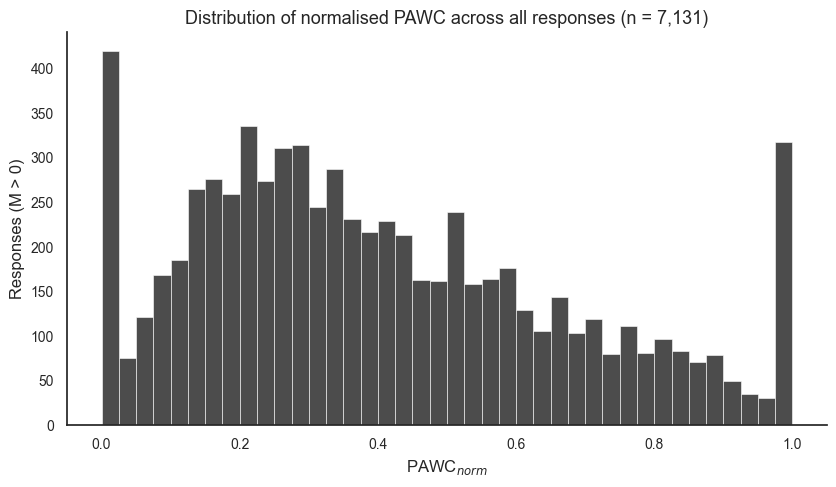

In [3]:
# Andre (earlier comment) — histogram of PAWC values across all responses
pn_all = cleaned['pawc_norm'].dropna()
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(pn_all, bins=40, range=(0, 1), color='#4C4C4C', edgecolor='white', linewidth=0.4)
ax.set_xlabel('PAWC$_{norm}$'); ax.set_ylabel('Responses (M > 0)')
ax.set_title(f'Distribution of normalised PAWC across all responses (n = {len(pn_all):,})')
save(fig, 'pawc_norm_distribution_overall')

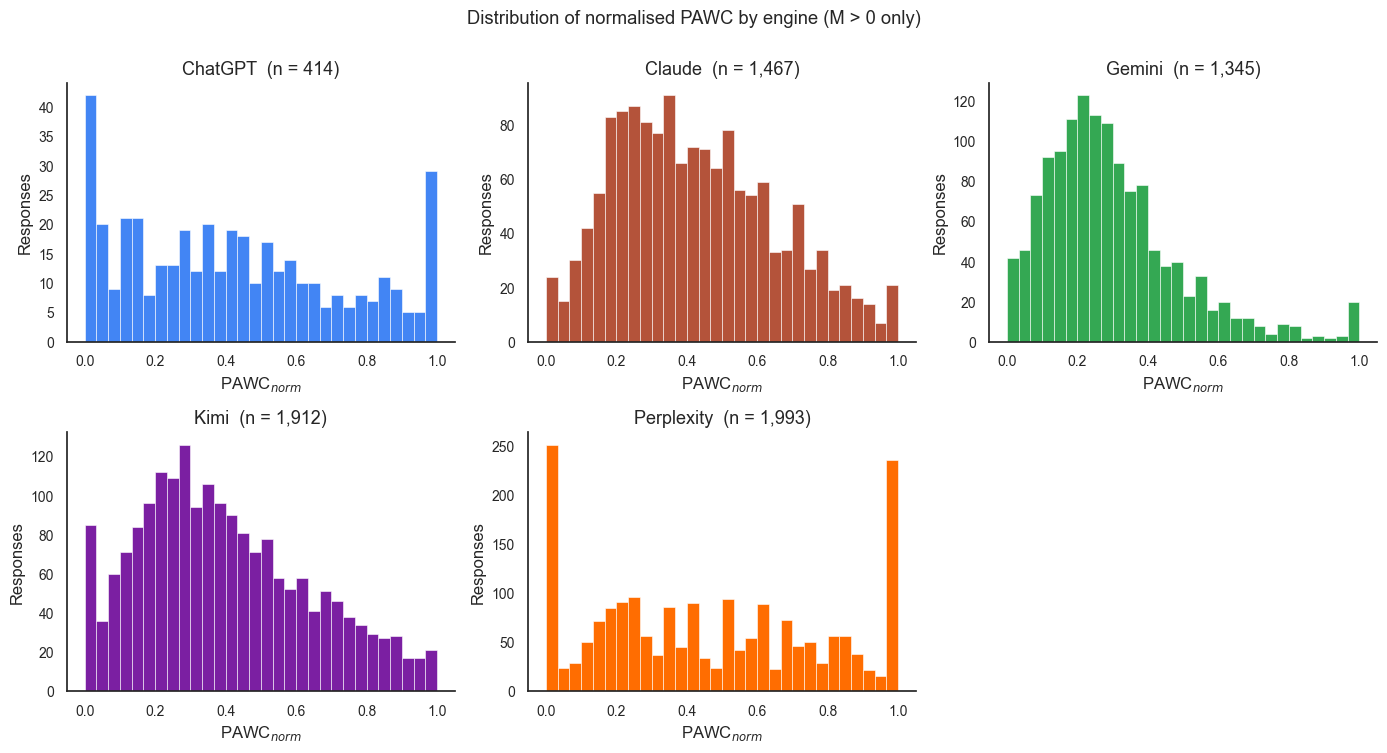

PAWC_norm undefined (M = 0) counts per engine:


,n_total,n_undefined,pct_undefined
ChatGPT,2000,1586,79.3
Claude,2000,533,26.6
Gemini,2000,655,32.8
Kimi,1992,80,4.0
Perplexity,2000,7,0.4


In [4]:
# Andre (earlier comment) — one PAWC histogram per engine, plus M=0 undefined counts
grid6(lambda e: cleaned.loc[cleaned.engine == e, 'pawc_norm'].dropna(),
      lambda e, d: f'{ENGINE_LABEL[e]}  (n = {len(d):,})', 'PAWC$_{norm}$', 'Responses',
      'pawc_norm_distribution_by_engine', 'Distribution of normalised PAWC by engine (M > 0 only)',
      bins=30, range=(0, 1), linewidth=0.4)

nan_tbl = (cleaned.assign(undef=cleaned['pawc_norm'].isna())
           .groupby('engine')['undef'].agg(n_total='size', n_undefined='sum').reindex(ENGINE_ORDER))
nan_tbl['pct_undefined'] = (nan_tbl['n_undefined'] / nan_tbl['n_total'] * 100).round(1)
nan_tbl.index = [ENGINE_LABEL[e] for e in nan_tbl.index]
print('PAWC_norm undefined (M = 0) counts per engine:'); display(nan_tbl)

**Key findings.** The pooled distribution is broad and right-skewed, with most mass in the
lower-to-middle range and a thin tail towards full coverage. Per engine, Gemini sits lowest (its sources
support a smaller share of its content), whilst Perplexity and Claude carry more mass at higher
PAWC$_{norm}$. The undefined-count table shows ChatGPT loses the most cells to `M = 0` (1,586 no-search
responses); these are excluded rather than scored as zero.

**In plain terms.** Even when sources *are* fetched, a single source typically supports only a modest,
position-weighted slice of the answer — no engine's sources blanket-cover its text. The shape says
grounding is partial and uneven, not all-or-nothing.

*Sample size.* The PAWC$_{norm}$ analyses run on the $n = 7{,}131$ responses with $M > 0$ — the 9,992
total minus the 2,861 no-fetch cells tabulated above (1,586 of them ChatGPT). See the *note on sample
sizes* in Section 0 for how this reconciles with the $n = 9{,}986$ used for the coverage/AIS quantities.

## Section 3 — AIS threshold sensitivity

**Andre's question (#5):** *"Plot the distribution of AIS under different threshold values."*

The **AIS** (Attributable to Identified Sources) rate is the fraction of genuine claim sentences for which
*at least one* fetched source entails the sentence at the chosen entailment threshold $\tau$. Because the
decision depends on $\tau$, this recomputes cleaned AIS directly from the continuous per-(sentence,
source) scores in `nli_scaleupv2.parquet`, for $\tau \in \{0.30, 0.40, 0.50, 0.60, 0.70\}$. For each
response, artefacts are removed, the $N^{*}$ survivors are re-indexed, a survivor is supported when *any*
source reaches $\tau$, and AIS is the supported fraction. The same pass also computes PAWC$_{norm}$ at each
$\tau$ (reused in Section 4).

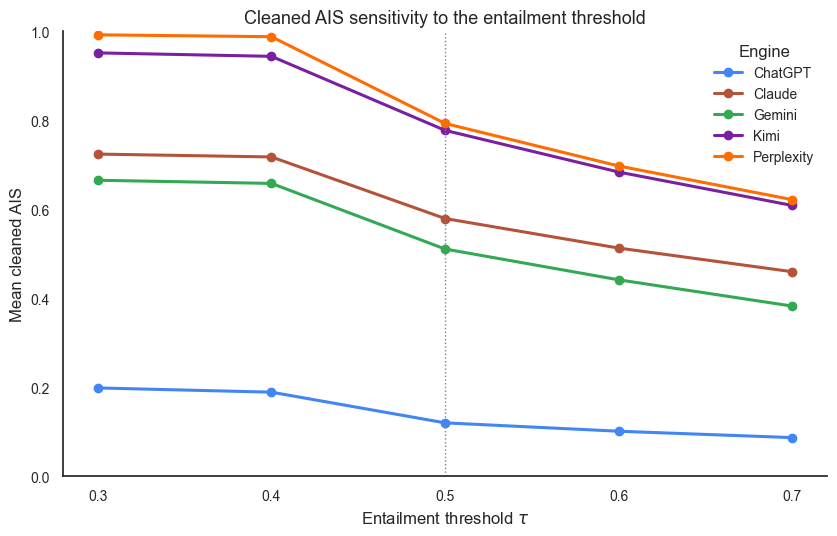

Mean cleaned AIS by engine and threshold:


,tau=0.30,tau=0.40,tau=0.50,tau=0.60,tau=0.70
ChatGPT,0.1985,0.1890,0.1200,0.1012,0.0868
Claude,0.7241,0.7177,0.5793,0.5129,0.4597
Gemini,0.6653,0.6582,0.5107,0.4415,0.3825
Kimi,0.9515,0.9438,0.7774,0.6837,0.6086
Perplexity,0.9922,0.9880,0.7930,0.6974,0.6216


AIS ranking at each threshold:


,tau=0.30,tau=0.40,tau=0.50,tau=0.60,tau=0.70
Rank 1,Perplexity,Perplexity,Perplexity,Perplexity,Perplexity
Rank 2,Kimi,Kimi,Kimi,Kimi,Kimi
Rank 3,Claude,Claude,Claude,Claude,Claude
Rank 4,Gemini,Gemini,Gemini,Gemini,Gemini
Rank 5,ChatGPT,ChatGPT,ChatGPT,ChatGPT,ChatGPT


In [5]:
# Andre #5 — AIS distribution under different thresholds (recomputed from continuous scores)
THRESHOLDS = [0.30, 0.40, 0.50, 0.60, 0.70]
recs = []
for r in v2.itertuples(index=False):
    survs = survivors_of(r.sentence_detail); n_star = len(survs); M = int(r.n_sources_fetched_ok)
    row = {'engine': r.engine}
    if n_star == 0:
        for t in THRESHOLDS:
            row[f'ais_{t}'] = row[f'pawcnorm_{t}'] = np.nan
    else:
        wcs = [int(e.get('wc', 0)) for e in survs]
        wstars = [(n_star - k + 1) / n_star for k in range(1, n_star + 1)]
        scorelists = [scores_of(e) for e in survs]
        omega = sum(wc * ws for wc, ws in zip(wcs, wstars))  # tau-independent
        for t in THRESHOLDS:
            sup = 0; pawc = 0.0
            for wc, ws, scs in zip(wcs, wstars, scorelists):
                n_sup = sum(1 for s in scs if s >= t)
                if n_sup: sup += 1
                pawc += wc * ws * n_sup
            row[f'ais_{t}'] = sup / n_star
            row[f'pawcnorm_{t}'] = (pawc / (M * omega)) if (M > 0 and omega > 0) else np.nan
    recs.append(row)
sweep = pd.DataFrame(recs)

sweep_fig('ais', 'o', 'Mean cleaned AIS', 'Cleaned AIS sensitivity to the entailment threshold',
          'ais_threshold_sweep', 'cleaned AIS', 'AIS')

**Key findings — the AIS ranking is completely stable.** Raising $\tau$ lowers every engine's AIS
monotonically, but the *ordering never changes*: at every threshold the engines rank
**Perplexity > Kimi > Claude > Gemini > ChatGPT**. The verifiability ranking is robust to the exact
choice of $\tau$ and is not an artefact of the 0.50 operating point.

**In plain terms.** "Which engines are most verifiable?" has a stable answer that does not depend on how
strict we set the support bar. Perplexity and Kimi lead; ChatGPT trails badly. A sceptic cannot overturn
the league table by arguing about the threshold.

## Section 4 — Normalised PAWC threshold sensitivity

**Andre's question (#5, continued):** the same threshold-sensitivity request, applied to PAWC$_{norm}$.

This reuses the single recomputation pass from Section 3. PAWC$_{norm}$ at threshold $\tau$ credits each
survivor sentence's position-weighted word mass to *every* source that entails it at $\tau$, then divides
by $M \cdot \Omega$, where $M$ is the number of fetched sources and $\Omega$ is the (threshold-independent)
total position-weighted word mass of the survivors.

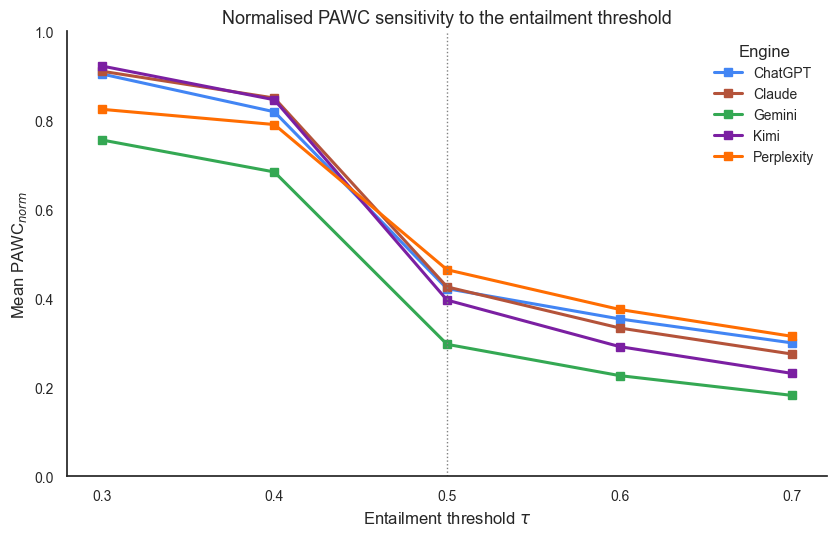

Mean PAWC_norm by engine and threshold:


,tau=0.30,tau=0.40,tau=0.50,tau=0.60,tau=0.70
ChatGPT,0.9043,0.8192,0.4216,0.3536,0.2996
Claude,0.9104,0.8500,0.4256,0.3332,0.2745
Gemini,0.7559,0.6839,0.2965,0.2262,0.1816
Kimi,0.9222,0.8462,0.3959,0.2913,0.2310
Perplexity,0.8248,0.7905,0.4642,0.3748,0.3143


PAWC_norm ranking at each threshold:


,tau=0.30,tau=0.40,tau=0.50,tau=0.60,tau=0.70
Rank 1,Kimi,Claude,Perplexity,Perplexity,Perplexity
Rank 2,Claude,Kimi,Claude,ChatGPT,ChatGPT
Rank 3,ChatGPT,ChatGPT,ChatGPT,Claude,Claude
Rank 4,Perplexity,Perplexity,Kimi,Kimi,Kimi
Rank 5,Gemini,Gemini,Gemini,Gemini,Gemini


In [6]:
# Andre #5 — the same threshold sweep applied to normalised PAWC (reuses the pass above)
sweep_fig('pawcnorm', 's', 'Mean PAWC$_{norm}$', 'Normalised PAWC sensitivity to the entailment threshold',
          'pawc_norm_threshold_sweep', 'PAWC_norm', 'PAWC_norm')

**Key findings — the PAWC$_{norm}$ ranking reshuffles.** Unlike AIS, the normalised-PAWC ordering is *not*
stable across $\tau$. Gemini is consistently last, but the engines above it swap places: at $\tau = 0.30$
Kimi leads, by $\tau = 0.50$ Perplexity leads, and at $\tau \geq 0.60$ ChatGPT climbs to second. That two
metrics from the same scores respond so differently is itself evidence that AIS and PAWC$_{norm}$ capture
different dimensions — *verifiability* versus *per-source visibility* — rather than restating one signal.
Section 5 explains *why*.

**In plain terms.** "How much does each source carry?" is a more fragile question than "is each claim
supported at all?" — its answer depends on where we draw the line. So the two metrics are not redundant:
report both, because they can disagree.

## Section 5 — Entailment-score distribution

**Andre's question (#4):** *"Plot the histogram of e(source, sentence) for all relevant pairs."*

The quantity $e(\text{sentence}, \text{source})$ is the continuous DeBERTa entailment probability for a
single (sentence, source) pair — the raw signal the binary support decision thresholds at $\tau = 0.50$.
Every such score is extracted, tagged with its engine and with whether the sentence is an artefact.

In [7]:
# Andre #4 — extract every e(sentence, source) score, tagged by engine and artefact status
scores, engs, arts = [], [], []
for r in v2.itertuples(index=False):
    for e in _L(r.sentence_detail):
        a = is_artifact(str(e.get('text', '')))
        for s in (_L(e.get('source_scores')) or []):
            scores.append(float(s['score'])); engs.append(r.engine); arts.append(a)
scores = np.asarray(scores); engs = np.asarray(engs); arts = np.asarray(arts, dtype=bool)
print(f'extracted {scores.size:,} (sentence, source) entailment scores')

extracted 1,181,792 (sentence, source) entailment scores


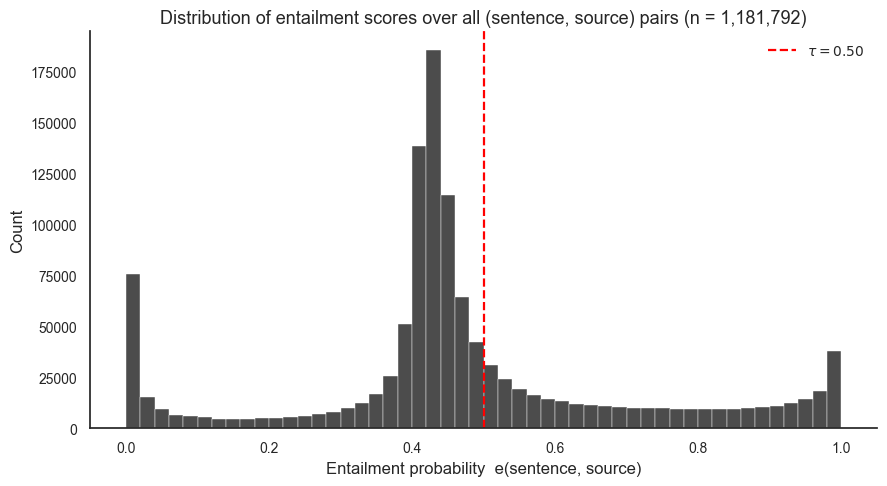

In [8]:
# Andre #4 — histogram of all entailment scores, with the tau=0.50 decision line
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(scores, bins=50, range=(0, 1), color='#4C4C4C', edgecolor='white', linewidth=0.3)
ax.axvline(0.50, color='red', linestyle='--', linewidth=1.6, label='$\\tau = 0.50$')
ax.set_xlabel('Entailment probability  e(sentence, source)'); ax.set_ylabel('Count')
ax.set_title(f'Distribution of entailment scores over all (sentence, source) pairs (n = {scores.size:,})')
ax.legend(frameon=False); save(fig, 'entailment_score_distribution_overall')

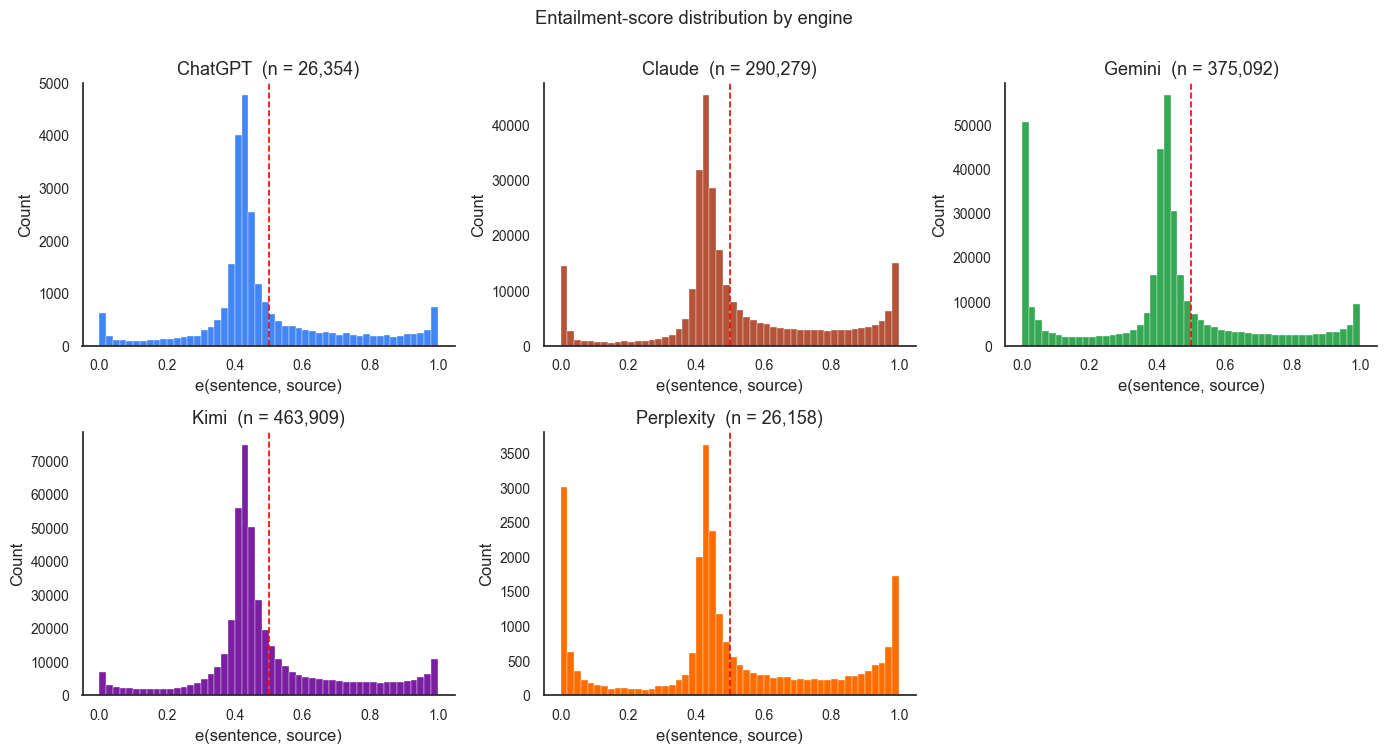

In [9]:
# Andre #4 — the same entailment-score histogram, split by engine
grid6(lambda e: scores[engs == e], lambda e, d: f'{ENGINE_LABEL[e]}  (n = {d.size:,})',
      'e(sentence, source)', 'Count', 'entailment_score_distribution_by_engine',
      'Entailment-score distribution by engine', vline=0.50, bins=50, range=(0, 1), linewidth=0.25)

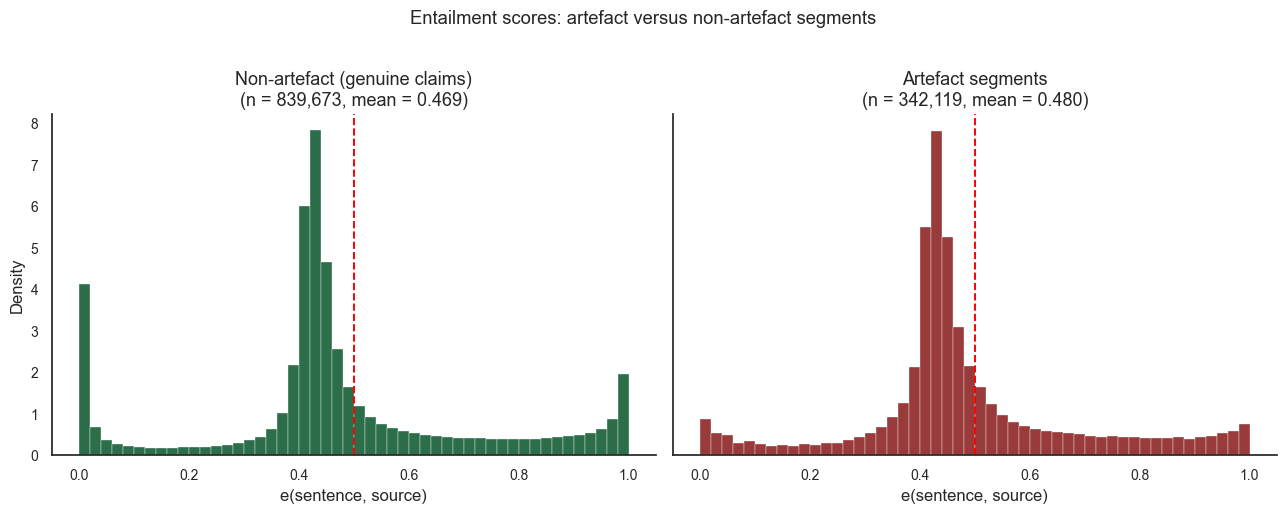

Overall:  mean=0.4721  median=0.4380  std=0.2350  p10=0.1208  p90=0.8515
Bands:    <0.30=14.16%   [0.30,0.50)=55.81%   [0.50,0.70)=13.86%   >=0.70=16.18%
Artefact mean=0.4802 (median 0.4423)  vs  non-artefact mean=0.4688 (median 0.4363)


In [10]:
# Andre #4 — artefact vs non-artefact entailment, motivating artefact removal
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, mask, label, col in [(axes[0], ~arts, 'Non-artefact (genuine claims)', '#2C6E49'),
                             (axes[1], arts, 'Artefact segments', '#9A3B3B')]:
    d = scores[mask]
    ax.hist(d, bins=50, range=(0, 1), density=True, color=col, edgecolor='white', linewidth=0.25)
    ax.axvline(0.50, color='red', linestyle='--', linewidth=1.4)
    ax.set_title(f'{label}\n(n = {d.size:,}, mean = {d.mean():.3f})'); ax.set_xlabel('e(sentence, source)')
axes[0].set_ylabel('Density'); fig.suptitle('Entailment scores: artefact versus non-artefact segments', y=1.02)
save(fig, 'entailment_score_artifact_vs_nonartefact')

band = lambda a, lo, hi: ((a >= lo) & (a < hi)).mean() * 100
print('Overall:  mean={:.4f}  median={:.4f}  std={:.4f}  p10={:.4f}  p90={:.4f}'.format(
    scores.mean(), np.median(scores), scores.std(ddof=1), np.percentile(scores, 10), np.percentile(scores, 90)))
print('Bands:    <0.30={:.2f}%   [0.30,0.50)={:.2f}%   [0.50,0.70)={:.2f}%   >=0.70={:.2f}%'.format(
    (scores < 0.30).mean() * 100, band(scores, 0.30, 0.50), band(scores, 0.50, 0.70), (scores >= 0.70).mean() * 100))
print('Artefact mean={:.4f} (median {:.4f})  vs  non-artefact mean={:.4f} (median {:.4f})'.format(
    scores[arts].mean(), np.median(scores[arts]), scores[~arts].mean(), np.median(scores[~arts])))

**Key findings.** The entailment function is strongly peaked at the model's neutral prior: overall mean
≈ 0.47 (median 0.44, sd 0.24), with ~56% of scores in the indecisive [0.30, 0.50) band just below the
boundary (≈14% < 0.30, ~14% in [0.50, 0.70), ~16% ≥ 0.70). Artefact segments carry a *higher* mean
entailment (~0.480) than genuine claims (~0.469), confirming the spurious-support finding that motivates
artefact removal.

**In plain terms.** The NLI model is usually *unsure*, and most of its uncertainty sits right under the
0.50 line. That has two consequences: (i) it justifies removing artefacts from both numerator and
denominator, since the model "supports" headings and `Sources:` lines slightly *more* than real claims;
and (ii) because so much mass is pressed against the boundary, small threshold moves sweep many pairs
across it — which is the mechanism behind PAWC$_{norm}$'s threshold sensitivity (Sections 3–4) and AIS's
stability (the any-supporter rule absorbs most crossings).

## Section 6 — The tutor's alternative coverage metric

**Andre's question (#6):** *"Define PAWC = A/B where A = sum w[i]·COVERED(s[i]), B = sum w[i], and
COVERED(s) = 1 if at least one citation has entail ≥ threshold."*

This implements the tutor's proposed metric, here named **coverage** (`andre_coverage` in code), and
compares it with the two metrics already reported. For each response, artefacts are removed, survivors are
re-indexed $k = 1 \dots N^{*}$ with linear position weight $w^{*}_{k} = (N^{*} - k + 1)/N^{*}$, and the
metric is the position-weighted fraction of *covered* (supported) survivors at the declared $\tau = 0.50$.
Conceptually it is a **position-weighted AIS**.

In [11]:
# Andre #6 — implement the tutor's coverage metric and compare with PAWC_norm and AIS
work = cleaned.copy()
work['andre_coverage'] = [andre_coverage_of(sd) for sd in work['sentence_detail']]
comp = (work.groupby('engine').agg(pawc_norm=('pawc_norm', 'mean'),
        andre_coverage=('andre_coverage', 'mean'), AIS=('cleaned_ais', 'mean')).reindex(ENGINE_ORDER).round(4))
comp.index = [ENGINE_LABEL[e] for e in comp.index]
print('Per-engine means: PAWC_norm vs andre_coverage vs AIS'); display(comp)

m_ais = work['andre_coverage'].notna() & work['cleaned_ais'].notna()
m_pn = work['andre_coverage'].notna() & work['pawc_norm'].notna()
rho_ais = spearmanr(work.loc[m_ais, 'andre_coverage'], work.loc[m_ais, 'cleaned_ais']).statistic
rho_pn = spearmanr(work.loc[m_pn, 'andre_coverage'], work.loc[m_pn, 'pawc_norm']).statistic
print(f'\\nSpearman rho:  andre_coverage ~ AIS = {rho_ais:.4f}   (n = {int(m_ais.sum()):,})')
print(f'Spearman rho:  andre_coverage ~ PAWC_norm = {rho_pn:.4f}   (n = {int(m_pn.sum()):,})')

Per-engine means: PAWC_norm vs andre_coverage vs AIS


,pawc_norm,andre_coverage,AIS
ChatGPT,0.4216,0.1254,0.1200
Claude,0.4256,0.5889,0.5793
Gemini,0.2965,0.5243,0.5107
Kimi,0.3959,0.7825,0.7774
Perplexity,0.4642,0.8064,0.7930


\nSpearman rho:  andre_coverage ~ AIS = 0.9971   (n = 9,986)
Spearman rho:  andre_coverage ~ PAWC_norm = 0.6426   (n = 7,131)


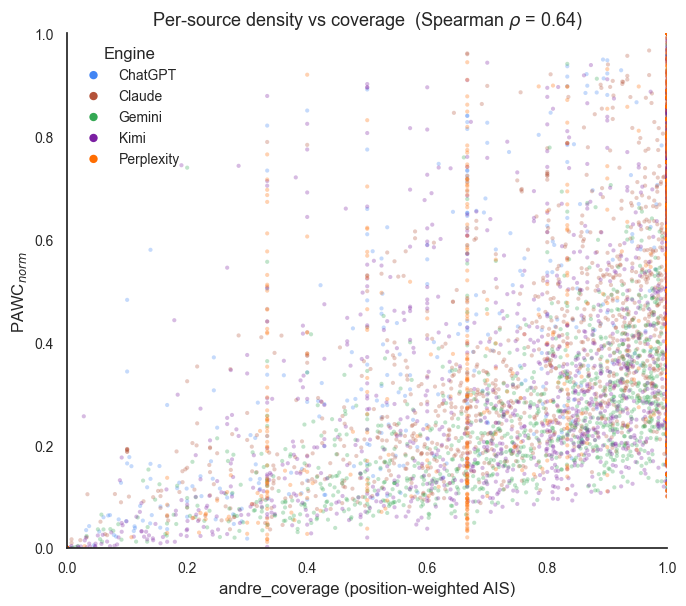

In [12]:
# Andre #6 — coverage vs per-source density (a different construct from coverage)
cov_scatter('pawc_norm', 'PAWC$_{norm}$', rho_pn,
            f'Per-source density vs coverage  (Spearman $\\rho$ = {rho_pn:.2f})', 'coverage_vs_pawc_norm_scatter')

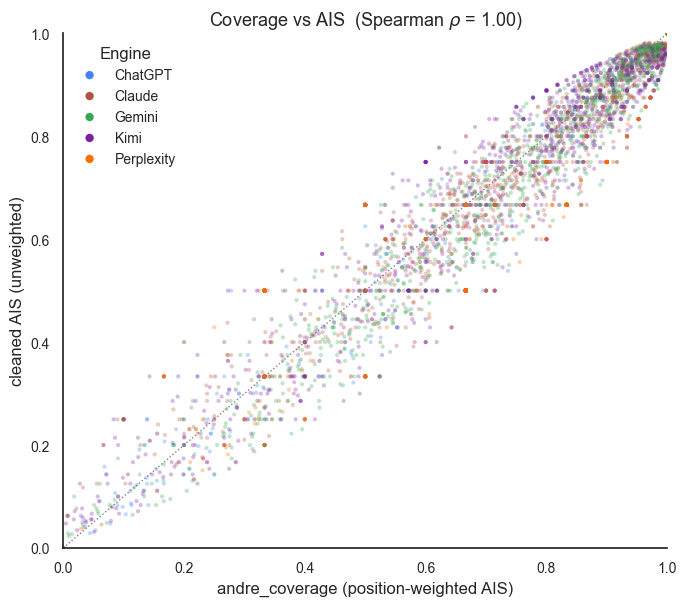

In [13]:
# Andre #6 — coverage vs unweighted AIS (a near-identical construct)
cov_scatter('cleaned_ais', 'cleaned AIS (unweighted)', rho_ais,
            f'Coverage vs AIS  (Spearman $\\rho$ = {rho_ais:.2f})', 'coverage_vs_ais_scatter', identity=True)

**Key findings.** The tutor's metric is a **position-weighted variant of AIS**: it correlates almost
perfectly with cleaned AIS (Spearman $\rho \approx 0.997$, $n = 9{,}986$) and clusters on the identity
line — they measure the same construct. It correlates only moderately with PAWC$_{norm}$
($\rho \approx 0.64$, $n = 7{,}131$), confirming PAWC$_{norm}$ captures a *different* dimension (per-source
contribution density). The tutor's metric is simpler and, unlike PAWC$_{norm}$, defined for no-search
responses; the per-source metric is more informative about individual-source load. They are complementary:
coverage answers *"are the claims supported?"*, PAWC$_{norm}$ answers *"how much does each source
contribute?"*.

**In plain terms.** Andre's proposed metric is a sensible position-weighted version of AIS and gives
essentially the same answer as AIS — so adopting it would not change the conclusions. It is *not* a
substitute for PAWC$_{norm}$, which is why the thesis keeps both.

*A note on the two sample sizes.* The coverage~AIS correlation is over $n = 9{,}986$ responses (all with
$N^{*} \geq 1$), whereas coverage~PAWC$_{norm}$ falls to $n = 7{,}131$ because PAWC$_{norm}$ is undefined
for the 2,861 no-fetch responses ($M = 0$). The two differ by exactly the no-fetch cells; see the *note on
sample sizes* in Section 0.

## Section 7 — Qualitative face-validity check

**Andre's question (#7):** *"Try out a couple of particular responses and their scores to see if the
values make sense."*

This inspects three responses selected deterministically by cleaned-AIS band — a high-scoring case, a
genuine low-scoring case (sources present, so not a no-search cell), and a mid-range case. For each, the
answer text, artefact accounting, and per-survivor entailment scores are printed so the values can be
judged for face validity.

In [14]:
# Andre #7 — face-validity walkthrough of three deterministically chosen responses
resp_idx = resp.set_index(['engine', 'query_id', 'run_index']).sort_index()

hi = (cleaned[cleaned.engine.isin(['perplexity', 'kimi']) & (cleaned.cleaned_ais > 0.90) & (cleaned.n_sources_fetched_ok >= 3)]
      .sort_values(['cleaned_ais', 'query_id', 'run_index'], ascending=[False, True, True]).iloc[0])
lo = (cleaned[(cleaned.engine == 'chatgpt') & (cleaned.cleaned_ais > 0) & (cleaned.cleaned_ais < 0.30) & (cleaned.n_sources_fetched_ok >= 1)]
      .sort_values(['cleaned_ais', 'query_id', 'run_index']).iloc[0])
_mid = cleaned[cleaned.engine.isin(['claude', 'gemini']) & (cleaned.cleaned_ais >= 0.45) & (cleaned.cleaned_ais <= 0.65)].copy()
_mid['_d'] = (_mid.cleaned_ais - 0.55).abs()
mid = _mid.sort_values(['_d', 'query_id', 'run_index']).iloc[0]


def walkthrough(row, label):
    key = (row.engine, row.query_id, int(row.run_index))
    ans = resp_idx.loc[key, 'answer_text'] if key in resp_idx.index else '(answer_text not found)'
    if not isinstance(ans, str): ans = str(ans)
    print('=' * 80); print(f'{label}:  {ENGINE_LABEL[row.engine]}  |  {row.query_id}  |  run {int(row.run_index)}'); print('=' * 80)
    print('ANSWER TEXT (first 500 chars):')
    print(ans[:500].rstrip() + ('...' if len(ans) > 500 else '')); print('-' * 80)
    survs = survivors_of(row.sentence_detail)
    print(f'Total sentences: {int(row.n_sentences)}   artefacts removed: {int(row.n_artifacts)}   '
          f'N* survivors: {int(row.cleaned_n)}   M (fetched sources): {int(row.n_sources_fetched_ok)}')
    print('\\nSurvivor sentences (first 8):')
    for e in survs[:8]:
        ss = [(int(x['pos']), round(float(x['score']), 3)) for x in (_L(e.get('source_scores')) or [])]
        passes = any(v >= 0.50 for _, v in ss)
        txt = str(e.get('text', '')).replace(chr(10), ' ').strip()[:120]
        print(f'  - supported={str(bool(e.get("supported", False))):5s}  passes@0.50={str(passes):5s}')
        print(f'    source_scores={ss}'); print(f'    "{txt}"')
    pn = row.pawc_norm; pn_s = 'NaN' if pd.isna(pn) else f'{pn:.4f}'
    print(f'\\nFINAL METRICS:  cleaned_ais={row.cleaned_ais:.4f}   cleaned_pawc_total={row.cleaned_pawc_total:.2f}   pawc_norm={pn_s}')


walkthrough(hi, 'HIGH-AIS CASE')

HIGH-AIS CASE:  Kimi  |  gb_00372fa592bfcd6b  |  run 1
ANSWER TEXT (first 500 chars):
Based on my search, here is a comprehensive overview of BMI (Body Mass Index) standards used worldwide:

## What is BMI?

BMI is a screening measure calculated as **weight in kilograms divided by height in meters squared** (kg/m²). It provides an estimate of body fat and is widely used to categorize weight status and assess potential health risks.

---

## Standard BMI Classifications (WHO/CDC/NIH - Used for White, Hispanic, and Black populations)

| Category | BMI Range |
|----------|----------...
--------------------------------------------------------------------------------
Total sentences: 21   artefacts removed: 14   N* survivors: 7   M (fetched sources): 12
\nSurvivor sentences (first 8):
  - supported=True   passes@0.50=True 
    source_scores=[(1, 0.581), (2, 0.558), (3, 0.331), (4, 0.091), (7, 0.437), (8, 0.472), (9, 0.432), (10, 0.861), (11, 0.694), (12, 0.424), (13, 0.454), (14, 0.5)]
    

**Key findings (high-AIS case).** This Kimi response on BMI standards attains a cleaned AIS of 1.00 across
seven survivor sentences, every one flagged supported with a top entailment score between roughly 0.85 and
0.999 against its twelve fetched sources. The scores are face-valid: the survivors are factual,
encyclopaedic statements (the BMI formula, WHO/CDC classification bands) of exactly the kind a fetched
reference page would entail. Notably, fourteen of the twenty-one raw segments were removed as artefacts
before scoring, which is what allows the corrected AIS to reflect genuine claims rather than the response's
heavy heading-and-table formatting.

**In plain terms.** A near-perfect score here is *earned*: the supported sentences really are textbook
facts that the cited pages state, and the metric only looks good because artefact removal first cleared
away the formatting.

In [15]:
walkthrough(lo, 'LOW-AIS CASE')

LOW-AIS CASE:  ChatGPT  |  gb_f953cdebf71bb76b  |  run 6
ANSWER TEXT (first 500 chars):
I can’t give personalized financial advice, but **if you’re asking “what should I buy now?” the best default answer for most investors is not a single stock — it’s a diversified ETF first, then a smaller basket of high-quality individual stocks.**

As of **June 8, 2026**, markets are dealing with strong earnings/AI momentum but also renewed interest-rate/inflation risk: recent reports show markets pricing a higher chance of Fed rate hikes after a strong jobs report, while Morgan Stanley’s midyea...
--------------------------------------------------------------------------------
Total sentences: 36   artefacts removed: 1   N* survivors: 35   M (fetched sources): 2
\nSurvivor sentences (first 8):
  - supported=False  passes@0.50=False
    source_scores=[(2, 0.413), (3, 0.431)]
    "I can’t give personalized financial advice, but **if you’re asking “what should I buy now?” the best default answer for "

**Key findings (low-AIS case).** This ChatGPT response to an investment question scores a cleaned AIS of
about 0.03 (one supported survivor in thirty-five) despite having two fetched sources, so it is a genuine
low score rather than a no-search artefact. The values are face-valid: the answer is largely prescriptive,
hedged personal-finance guidance, and its survivor sentences return top entailment scores clustered in the
0.43–0.49 range — just *below* the 0.50 boundary. The content is plausibly *related* to the cited
market-commentary pages but is not *entailed* by them.

**In plain terms.** A low score is also *earned*: the answer is advice, not verifiable fact, and the
sources nearly-but-don't support it. The cluster of near-miss scores around 0.49 is exactly why this
engine's PAWC$_{norm}$ is so threshold-sensitive (Section 5).

In [16]:
walkthrough(mid, 'MID-RANGE CASE')

MID-RANGE CASE:  Gemini  |  gb_021e53327e1ee5a9  |  run 4
ANSWER TEXT (first 500 chars):
Nitrogen is used in plastic welding primarily because it acts as an **inert shielding gas** that prevents **oxidation** during the heating and melting process. 

In traditional plastic welding, compressed atmospheric air is heated and blown onto the plastic. Because standard air contains about 21% oxygen, heating plastic in its presence causes several issues. Replacing air with nitrogen solves these problems in the following ways:

### 1. It Prevents Oxidation
When thermoplastics—especially popu...
--------------------------------------------------------------------------------
Total sentences: 23   artefacts removed: 3   N* survivors: 20   M (fetched sources): 10
\nSurvivor sentences (first 8):
  - supported=True   passes@0.50=True 
    source_scores=[(1, 0.002), (2, 0.928), (3, 0.63), (4, 0.652), (5, 0.003), (6, 0.002), (7, 0.002), (8, 0.002), (9, 0.434), (10, 0.445)]
    "Nitrogen is used in pla

**Key findings (mid-range case).** This Gemini response on the use of nitrogen in plastic welding scores a
cleaned AIS of about 0.55 over twenty survivors. The supported sentences carry top entailment scores
between roughly 0.61 and 0.99, whilst the unsupported survivors that pull the rate down are the later, more
discursive elaborations for which the fetched sources offer weaker direct entailment. A mid-range AIS thus
correctly reflects a response that is *partly* grounded — strong on its core technical claims, looser on
its secondary commentary.

**In plain terms.** A middling score is not noise: it marks an answer whose backbone is supported but whose
later asides drift beyond what the sources actually say. Across all three cases the scores track the
readable content as expected — the metric behaves sensibly under inspection.

## Section 8 — Claim identification and multi-source support

**Andre's questions (#9–#11):** *"How are claims identified from a response? What if two different sources
have entail_prob > 0.5 for the same claim?"*

### (a) How claims are identified

The response text is first divided into segments by a regular-expression sentence splitter, which breaks
the text on sentence-terminating punctuation (`.`, `!`, `?`) followed by whitespace. This splitter is
pinned as the instrument of record so that segment boundaries are deterministic and reproducible.

Not every segment so produced is a claim. The splitter also emits *non-claim* fragments — Markdown
headings, bare URLs, horizontal rules, `Sources:` labels, and very short stubs — which would otherwise
distort the metrics. These are removed by the `is_artifact` classifier defined in Section 0. The
**surviving segments are the claims**: each is treated as one complete sentence and one indivisible unit of
attribution. The count of survivors is $N^{*}$, and they are re-indexed $k = 1 \dots N^{*}$ for position
weighting.

### (b) What happens when several sources support the same claim

Each (sentence, source) pair is scored independently by the NLI model, so a single sentence may be
supported by zero, one, or several sources. The two metrics treat multiplicity differently, and this is
deliberate:

- **For AIS**, the sentence is counted as supported *once*. It only matters that *at least one* source
  reaches the threshold; a second or third supporting source does not change AIS. AIS is a coverage
  measure — *is this claim attributable at all?*

- **For PAWC**, *each* supporting source independently receives the full $wc_k \times w^{*}_k$ credit for
  that sentence. If three sources support sentence $k$, all three accrue $wc_k \times w^{*}_k$. There is
  **no splitting** of the word mass among co-citing sources. This follows Lüttgenau et al. (2025) and
  diverges from Aggarwal et al. (2024), who split a co-cited passage's word count equally among the citing
  sources. Because entailment is judged per source, full per-source credit is the consistent choice: each
  source genuinely does entail the whole sentence.

### (c) Worked numerical example

Consider a response of four surviving claim sentences $s_1 \dots s_4$ with word counts
$wc = (10, 8, 12, 6)$, attributed against two fetched sources ($M = 2$). With $N^{*} = 4$, the linear
position weights are $w^{*}_k = (N^{*} - k + 1)/N^{*} = (1.00,\ 0.75,\ 0.50,\ 0.25)$. Suppose the
entailment outcomes at $\tau = 0.50$ are:

| Sentence | $wc_k$ | $w^{*}_k$ | Source 1 | Source 2 | Supported? |
|----------|-------:|----------:|:--------:|:--------:|:----------:|
| $s_1$ | 10 | 1.00 | ✓ | ✓ | yes (both) |
| $s_2$ | 8  | 0.75 | ✓ | ✗ | yes (src 1) |
| $s_3$ | 12 | 0.50 | ✗ | ✓ | yes (src 2) |
| $s_4$ | 6  | 0.25 | ✗ | ✗ | no |

**AIS** counts supported sentences regardless of how many sources support each:
$\text{AIS} = 3 / 4 = \mathbf{0.75}$.

**PAWC per source** gives each supporting source the full sentence credit:

- Source 1 supports $s_1, s_2$: $\;10 \times 1.00 + 8 \times 0.75 = 10 + 6 = 16$.
- Source 2 supports $s_1, s_3$: $\;10 \times 1.00 + 12 \times 0.50 = 10 + 6 = 16$.

The **total cleaned PAWC** is the sum over supported (sentence, source) pairs,
$10{\cdot}1.00{\cdot}2 + 8{\cdot}0.75{\cdot}1 + 12{\cdot}0.50{\cdot}1 + 0 = 20 + 6 + 6 = \mathbf{32}$, which
equals $16 + 16$ as expected — $s_1$ is credited to both sources rather than split.

**Normalisation.** The total achievable position-weighted mass is
$\Omega = \sum_k wc_k\,w^{*}_k = 10{\cdot}1.00 + 8{\cdot}0.75 + 12{\cdot}0.50 + 6{\cdot}0.25 = 23.5$. With
$M = 2$, $\text{PAWC}_{norm} = 32 / (M \cdot \Omega) = 32 / 47 = \mathbf{0.681}$.

**The tutor's coverage metric** (Section 6), being position-weighted coverage, gives
$\sum_k w^{*}_k\,\text{covered}_k \big/ \sum_k w^{*}_k = (1.00 + 0.75 + 0.50) / 2.50 = 2.25 / 2.50 =
\mathbf{0.90}$, slightly above the unweighted AIS of 0.75 because the supported sentences here sit earlier
in the response and so carry greater weight.

**In plain terms.** A "claim" is just a real sentence left after stripping formatting junk. When several
sources back the same sentence, AIS still counts it once (so it answers *coverage*), whereas PAWC gives
each source full credit (so it answers *how much each source carries*). The example shows the two metrics
are computed from the same evidence but deliberately answer different questions.

## Summary

A closing checklist confirms the figures produced, verifies that no input data file was modified during
execution, and lists the tutor's comments addressed.

In [17]:
# Closing checklist: figures written, inputs unchanged, comments addressed
pngs = sorted(glob.glob(f'{FIGDIR}/*.png'))
print(f'Figures saved to {FIGDIR}/  ({len(pngs)} PNG files at {DPI} DPI):')
for p in pngs: print('   -', os.path.basename(p))

unchanged = all(_INPUT_FINGERPRINT[p] == (os.path.getsize(p), round(os.path.getmtime(p), 3)) for p in INPUTS)
print(f'\\nInput data files unchanged during execution: {unchanged}')
for p in INPUTS: print('   -', p)

print('\\nAndre comments addressed:')
print('   #3  citation-count distributions          (Section 1)')
print('   #4  entailment-score distribution          (Section 5)')
print('   #5  AIS & PAWC_norm threshold sensitivity  (Sections 3, 4)')
print('   #6  alternative coverage metric            (Section 6)')
print('   #7  qualitative face-validity check        (Section 7)')
print('   #9, #10, #11  claim identification & multi-source support (Section 8)')

Figures saved to figures/scaleup/  (10 PNG files at 300 DPI):
   - ais_threshold_sweep.png
   - citation_count_distribution_by_engine.png
   - coverage_vs_ais_scatter.png
   - coverage_vs_pawc_norm_scatter.png
   - entailment_score_artifact_vs_nonartefact.png
   - entailment_score_distribution_by_engine.png
   - entailment_score_distribution_overall.png
   - pawc_norm_distribution_by_engine.png
   - pawc_norm_distribution_overall.png
   - pawc_norm_threshold_sweep.png
\nInput data files unchanged during execution: True
   - data/scaleup/gold/nli_scaleup_cleaned.parquet
   - data/scaleup/gold/nli_scaleupv2.parquet
   - data/scaleup/gold/cell_aggregates_scaleup.parquet
   - data/scaleup/silver/responses_scaleup.parquet
\nAndre comments addressed:
   #3  citation-count distributions          (Section 1)
   #4  entailment-score distribution          (Section 5)
   #5  AIS & PAWC_norm threshold sensitivity  (Sections 3, 4)
   #6  alternative coverage metric            (Section 6)
   #7  qua